# 직무별 채용 공고 EDA

**분석 질문:** BE·DA·DE의 관측 공고 구성, 기술 키워드와 원천 간 중복은 어떻게 다른가?

사람인·잡코리아·인크루트·링커리어의 실제 저장 자료를 분석한다. [ETL 노트북](job_platform_etl.ipynb)은 수집·재시도·원본 분리·멱등성을 검증한다. 이 파일은 공고 구성·변화·기술과 결측을 집계하고 실제 관측값을 시각화한다.

2026-10-02 09:00~20:00 KST가 계획 범위이며 실제 수집은 12:50부터 시작했다. 오전 23틱은 좌절단이다. 20:00 전 출력은 부분 관측이고 빠진 시간의 값을 채우지 않는다.

분석 단위는 **통합 공고**다. 대표 조건은 게시 시각 정밀도·첫 관측·원천 순으로 한 공고를 선택한다. 기술·역량은 출처 합집합, 직무별 분모는 해당 직무의 통합 공고 수다. 복수 직무를 포함하므로 직무 합계는 전체 합계와 다를 수 있다. 중복 통합은 유사도에 따른 추정이며 실제 고용 인원·전체 시장 규모를 뜻하지 않는다.

In [1]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
assert (ROOT/'src/jobtrend').is_dir(), '프로젝트 루트에서 실행하세요'
sys.path.insert(0,str(ROOT/'src'))
from dotenv import load_dotenv
load_dotenv(ROOT/'.env')
from IPython.display import display,Markdown
import pandas as pd
from jobtrend import analysis as eda,store
pd.set_option('display.max_colwidth',90)
eda.setup_plots()
snapshot=eda.load_snapshot() # 모든 쿼리가 동일한 READ ONLY REPEATABLE READ 스냅샷
validation=eda.validate(snapshot)
catalog_evidence=eda.export_catalog(snapshot)
print('분석 기준 슬롯:',snapshot['asof'])
display(pd.DataFrame([catalog_evidence]))
print('SQL/pandas 독립 검증:',validation)
display(snapshot['catalog'].head(5)[['company_name','title','job_groups','sources','is_open']])

분석 기준 슬롯: 2026-10-02 16:50:00+09:00


,canonical_rows,platform_rows,source_links
0,4571,4964,4964


SQL/pandas 독립 검증: {'canonical_coverage': 4571, 'platform_postings': 4964, 'company_sql_pandas': True, 'window_sql_pandas': True, 'flow_sql_set_pandas': True, 'skill_sql_pandas': True}


,company_name,title,job_groups,sources,is_open
0,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,"[DA, DE]",[incruit],True
1,(주)안랩,[신입/경력] 디지털 포렌식,[DE],[incruit],True
2,한화에어로스페이스,[한화에어로스페이스] AI 인력 상시 경력 채용,[DE],[incruit],True
3,(주)이노션,AI 엔지니어 (Data/Analytics),[DA],[incruit],True
4,(주)이노션,[이노션] 데이터 분석 및 컨설팅 (Junior) (상시채용 인재풀),"[DA, DE]","[incruit, jobkorea]",True


## 1. 결측과 유효성부터 확인

**목적:** 원천이 제공하지 않는 값과 파싱 오류를 구분하고 비교 가능한 변수만 해석한다. 결측률은 플랫폼 공고 단위이며 통합 대표 조건의 결측률과 다르다. 상시·채용시 마감은 실제 날짜가 없으므로 의미 있는 NULL로 분리한다.

,platform,n,posted_at,sido,career_min_yr,education,deadline_unknown,meaningful_deadline_null,employment_type
0,incruit,170,0.0000,0.0294,0.2000,0.0000,0.0000,0.5412,0.0000
1,jobkorea,2055,0.0000,0.0073,0.1961,0.0350,0.0117,0.1509,0.0131
2,linkareer,121,0.0000,0.0083,0.4463,0.0744,0.0000,0.5702,0.7355
3,saramin,2618,0.0413,0.0092,0.2154,0.0000,0.0000,0.1971,0.0004


,platform,n,deadline_before_posted,invalid_career,sentinel_leaks,required_missing
0,incruit,170,0,0,0,0
1,jobkorea,2055,0,0,0,0
2,linkareer,121,0,0,0,0
3,saramin,2618,0,0,0,0


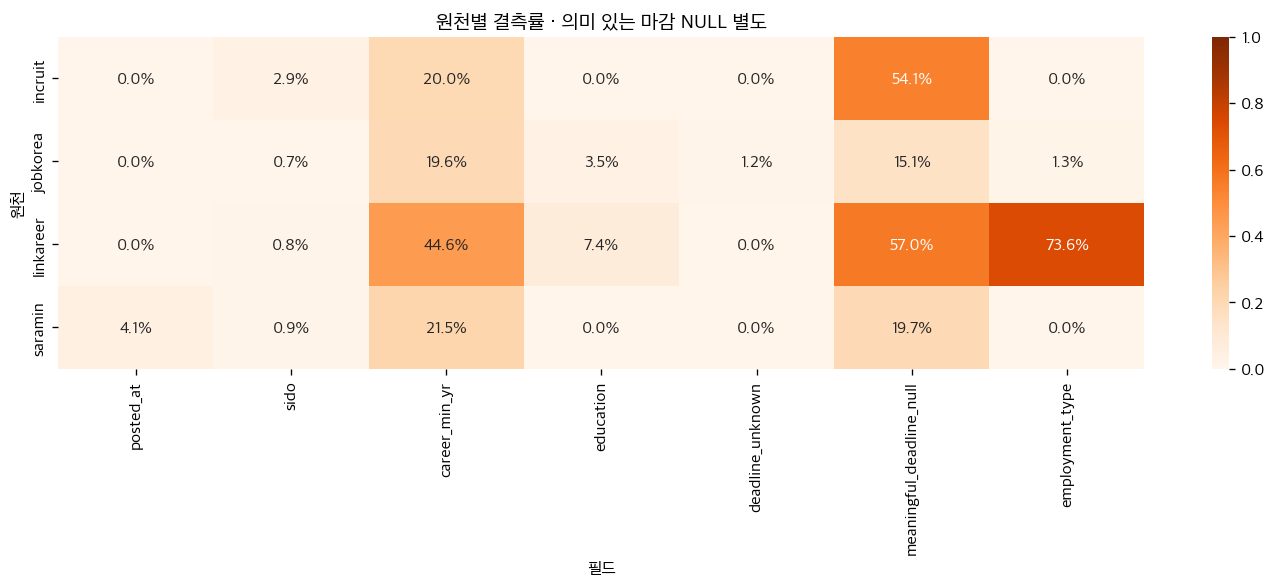

✍️ 목록이 제공하지 않는 학력·고용형태는 구조적 결측, 상시·채용시 마감일은 의미 있는 NULL, 상세 수집 대기와 수정 시각은 부분 결측, 양의 표시 총건수인데 파싱 0건인 경우는 파싱 실패로 구분한다. 매칭에 필요한 회사·제목·URL과 유효성 규칙을 별도로 점검했다.

In [2]:
display(snapshot['missingness'].round(4))
display(snapshot['validity'])
assert snapshot['validity'].sentinel_leaks.sum()==0
assert snapshot['validity'].required_missing.sum()==0
assert not ((snapshot['quality'].check_name=='privacy_patterns') & (snapshot['quality'].metric.astype(float)>0)).any()
display(Markdown(eda.chart_quality(snapshot)))

## 2. Q1·Q2 관측 공고의 변화

**목적:** 표시 총건수의 증감과 실제 목록 ID의 등장·이탈을 구분한다. Q1은 `LAG`·3슬롯 `AVG OVER`로 변화와 30분 평균을 계산한다. 링커리어는 혼합 IT 전수 목록에서 분류된 수이며 다른 플랫폼의 표시 총건수와 정의가 다르다. Q2는 연속 완료 전수의 `EXCEPT`로 유입·이탈을 계산한다. 첫 관측은 기준선으로만 사용한다.

차트는 실제 관측 구간만 표시하며 원천별 최초 관측=100 지수로 변화 크기를 비교한다. 오전 공백과 이후 예정 시간은 집계 표의 결측으로 유지한다. 목록 ID의 이탈은 채용 성사를 뜻하지 않는다.

In [3]:
for name in ('Q1','Q2'):
    display(Markdown('**'+name+' 집계 SQL**\n```sql\n'+eda.QUERIES[name].strip()+'\n```'))
q1=snapshot['Q1'];observed=q1[q1.inventory.notna()]
display(observed.groupby(['platform','job_group']).tail(1)[['platform','job_group','slot_ts','inventory','delta_10min','ma30']])
display(snapshot['Q2'][snapshot['Q2'].prev_slot.notna()].tail(12))

**Q1 집계 SQL**
```sql
WITH observed AS (
 SELECT m.platform,m.job_group,m.slot_ts,
  coalesce(m.reported_total,CASE WHEN m.is_complete THEN m.items_unique END)::numeric AS inventory,
  '표시 총건수/전수 ID'::text AS definition FROM v_listing_scope m WHERE job_group<>'MIX' AND status='ok'
 UNION ALL
 SELECT m.platform,g.job_group,m.slot_ts,
  CASE WHEN m.is_complete THEN (SELECT count(DISTINCT s.posting_id) FROM v_snapshot_scope s
    WHERE s.run_key=m.run_key AND s.platform=m.platform AND s.job_group=g.job_group) END::numeric,
  '혼합 목록 전수의 직무 분류' FROM v_listing_scope m CROSS JOIN (VALUES('BE'),('DA'),('DE')) g(job_group)
 WHERE m.job_group='MIX' AND m.status='ok'
), grid AS (
 SELECT s.slot_ts,k.platform,k.job_group,o.inventory,o.definition
 FROM generate_series(timestamptz '2026-10-02 09:00+09',timestamptz '2026-10-02 20:00+09',interval '10 minutes') s(slot_ts)
 CROSS JOIN (SELECT DISTINCT platform,job_group FROM observed) k
 LEFT JOIN observed o USING(slot_ts,platform,job_group)
), w AS (
 SELECT *,inventory-lag(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts) AS delta_10min,
  CASE WHEN count(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)=3
   THEN avg(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) END AS ma30,
  first_value(inventory) OVER(PARTITION BY platform,job_group ORDER BY (inventory IS NULL),slot_ts) AS baseline FROM grid
) SELECT *,100*inventory/nullif(baseline,0) AS idx100 FROM w ORDER BY platform,job_group,slot_ts
```

**Q2 집계 SQL**
```sql
WITH fulls AS (
 SELECT *,lag(run_key) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS prev_run,
  lag(slot_ts) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS prev_slot
 FROM v_listing_scope WHERE is_complete
), counts AS (
 SELECT f.platform,f.query_key,f.job_group,f.slot_ts,f.prev_slot,
  (SELECT count(DISTINCT posting_id) FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key) AS current_n,
  (SELECT count(DISTINCT posting_id) FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key) AS previous_n,
  CASE WHEN f.prev_run IS NOT NULL THEN (SELECT count(*) FROM
   (SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key
    EXCEPT SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key) a) END AS added,
  CASE WHEN f.prev_run IS NOT NULL THEN (SELECT count(*) FROM
   (SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key
    EXCEPT SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key) a) END AS removed
 FROM fulls f
) SELECT *,sum(added) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS cum_added,
 sum(removed) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS cum_removed FROM counts ORDER BY platform,query_key,slot_ts
```

,platform,job_group,slot_ts,inventory,delta_10min,ma30
47,incruit,BE,2026-10-02 16:50:00+09:00,62,0,62.0000000000000000
114,incruit,DA,2026-10-02 16:50:00+09:00,83,1,82.3333333333333333
181,incruit,DE,2026-10-02 16:50:00+09:00,41,0,41.0000000000000000
248,jobkorea,BE,2026-10-02 16:50:00+09:00,1623,0,1622.3333333333333333
315,jobkorea,DA,2026-10-02 16:50:00+09:00,131,0,131.0000000000000000
382,jobkorea,DE,2026-10-02 16:50:00+09:00,381,0,381.0000000000000000
444,linkareer,BE,2026-10-02 16:00:00+09:00,65,None,None
511,linkareer,DA,2026-10-02 16:00:00+09:00,63,None,None
578,linkareer,DE,2026-10-02 16:00:00+09:00,19,None,None
650,saramin,BE,2026-10-02 16:50:00+09:00,1784,-1,1783.0000000000000000


,platform,query_key,job_group,slot_ts,prev_slot,current_n,previous_n,added,removed,cum_added,cum_removed
80,saramin,BE,BE,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,1766,1766,0.0,0.0,0,0
81,saramin,BE,BE,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,1767,1766,9.0,8.0,9,8
82,saramin,BE,BE,2026-10-02 15:00:00+09:00,2026-10-02 14:00:00+09:00,1776,1767,10.0,1.0,19,9
83,saramin,BE,BE,2026-10-02 16:00:00+09:00,2026-10-02 15:00:00+09:00,1779,1776,6.0,3.0,25,12
85,saramin,DA,DA,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,673,673,0.0,0.0,0,0
86,saramin,DA,DA,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,676,673,3.0,0.0,3,0
87,saramin,DA,DA,2026-10-02 15:00:00+09:00,2026-10-02 14:00:00+09:00,676,676,1.0,1.0,4,1
88,saramin,DA,DA,2026-10-02 16:00:00+09:00,2026-10-02 15:00:00+09:00,677,676,3.0,2.0,7,3
90,saramin,DE,DE,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,785,785,0.0,0.0,0,0
91,saramin,DE,DE,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,787,785,4.0,2.0,4,2


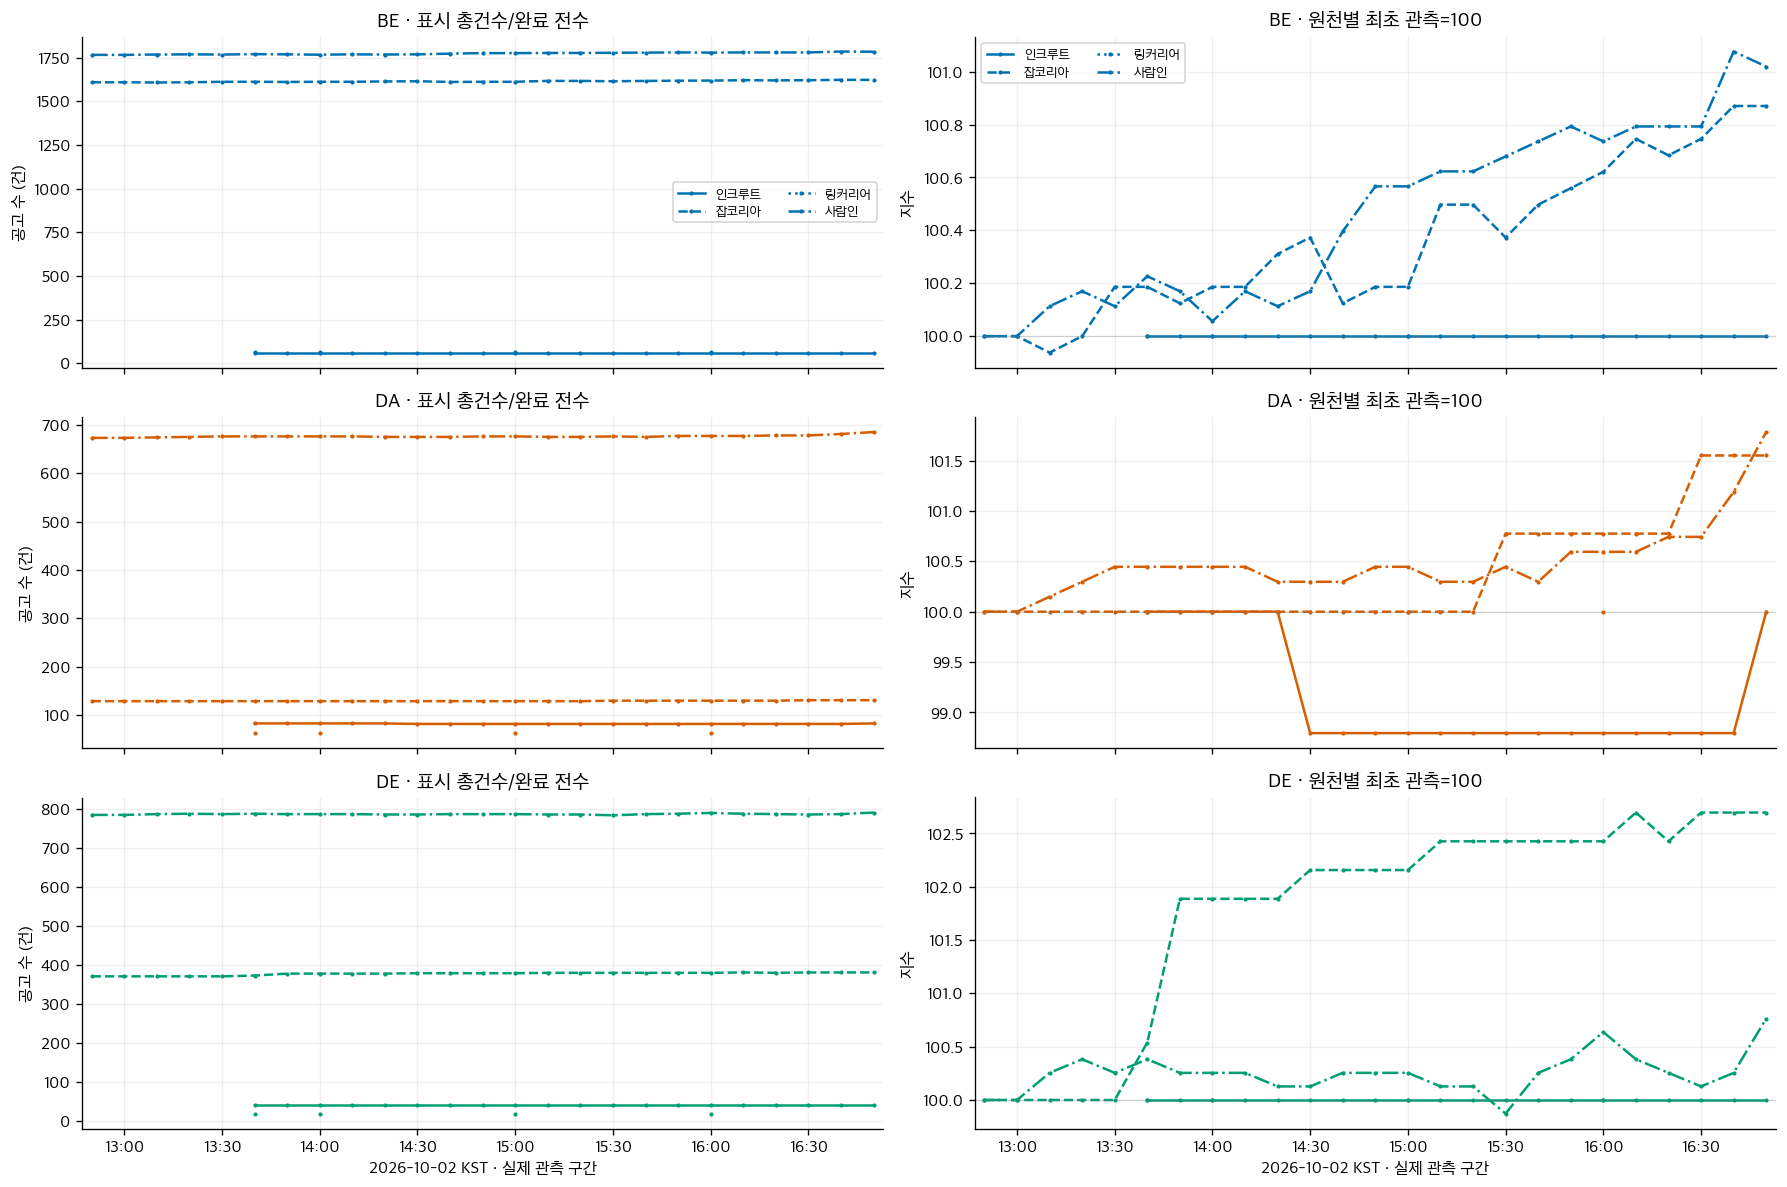

✍️ 확인된 원천·직무·슬롯 관측값은 222개다. 오전 가동 전과 아직 도래하지 않은 슬롯은 결측이며, 링커리어는 전수 스캔 시점의 분류 건수만 표시한다. 원천 간 총건수 정의가 달라 크기를 직접 시장 점유율로 해석할 수 없다.

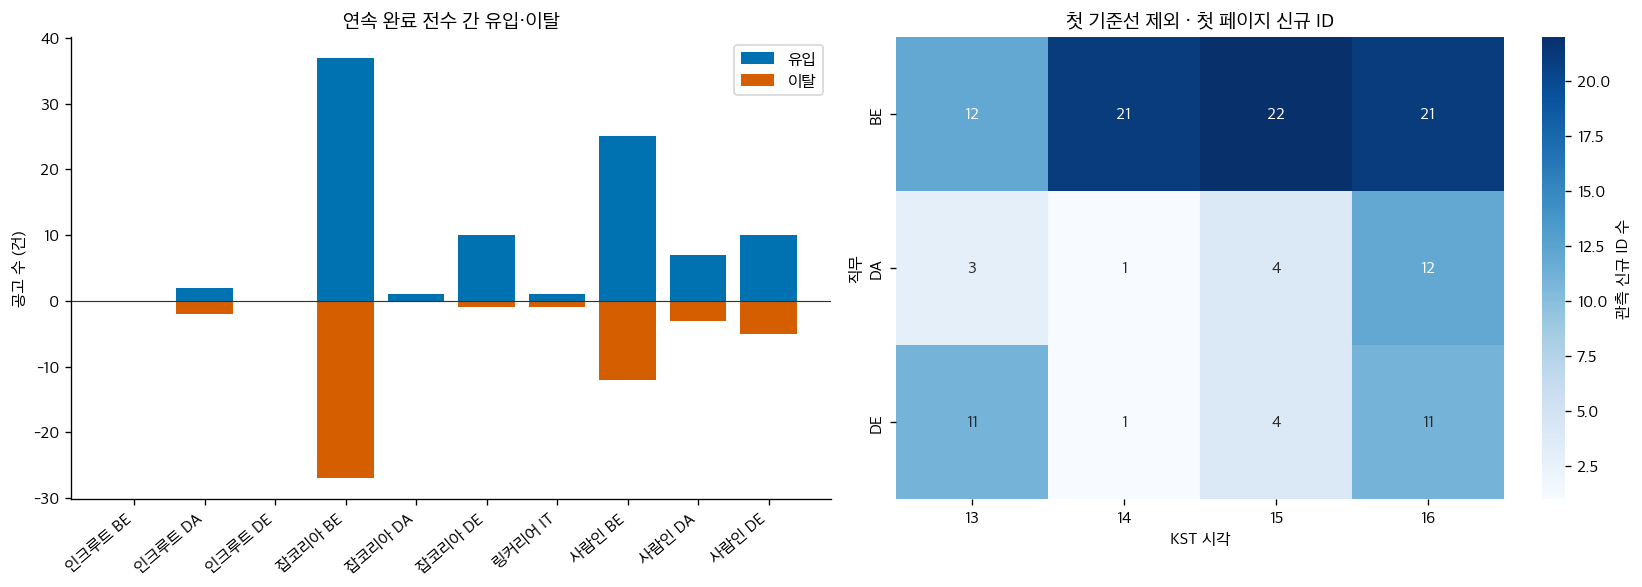

✍️ 비교 가능한 전수 간격 84개에서 유입 93건, 이탈 51건을 관측했다. 이는 최초 게시·실제 채용 성사 건수가 아니라 목록 ID의 등장·부재다. 같은 공고의 직무 중복과 시간 간격 차이가 있으므로 각 원천·질의 안에서 비교한다.

In [4]:
display(Markdown(eda.chart_q1(snapshot)))
display(Markdown(eda.chart_q2(snapshot)))

## 3. Q3·Q4 기업 집중도와 지원 조건

**목적:** 소수 기업의 다수 공고가 전체 수요를 부풀리는지 살펴보고 직무별 경력 문턱·지역·마감 구성을 비교한다. 회사명 정규화 후 `DENSE_RANK`·`NTILE`·누적 점유율로 집중도를 집계한다. 경력의 `PERCENTILE_CONT`는 결측을 제외한다. 대표 조건이 서로 다른 플랫폼에서 선택될 수 있으므로 원천별 결측을 함께 읽는다.

```sql
WITH company AS (SELECT c.company_key,min(j.company_name) company_name,count(*) n
 FROM v_job_scope j JOIN job_canonical c USING(canonical_id) GROUP BY c.company_key)
SELECT *,dense_rank() OVER(ORDER BY n DESC) ranking, ntile(20) OVER(ORDER BY n DESC,company_key) bucket20,
 n::numeric/sum(n) OVER() AS share, sum(n) OVER(ORDER BY n DESC,company_key ROWS UNBOUNDED PRECEDING)::numeric/sum(n) OVER() AS cum_share
FROM company ORDER BY n DESC,company_key
```

,company_name,n,ranking,share,cum_share
0,(주)사람인에이치에스,33,1,0.00721942682126449355,0.00721942682126449355
1,메가존클라우드,31,2,0.00678188580179391818,0.01400131262305841173
2,넛지헬스케어 주식회사,29,3,0.00634434478232334281,0.02034565740538175454
3,조인아이티,22,4,0.00481295121417632903,0.02515860861955808357
4,넥스트증권 주식회사,16,5,0.00350032815576460293,0.02865893677532268650
5,카카오페이,16,5,0.00350032815576460293,0.03215926493108728943
6,인터엑스,14,6,0.00306278713629402757,0.03522205206738131700
7,휴먼코어랩(주),14,6,0.00306278713629402757,0.03828483920367534456
8,(주)이테크시스템,13,7,0.00284401662655873988,0.04112885583023408445
9,카카오,12,8,0.00262524611682345220,0.04375410194705753664


,job_group,career_type,n,share,median_min_years
0,BE,any,425,0.12977099236641221374,NaN
1,BE,exp,2360,0.72061068702290076336,4.0
2,BE,new,146,0.04458015267175572519,0.0
3,BE,new_or_exp,338,0.10320610687022900763,0.0
4,BE,unknown,6,0.00183206106870229008,NaN
5,DA,any,213,0.22444678609062170706,NaN
6,DA,exp,529,0.55742887249736564805,3.0
7,DA,new,66,0.06954689146469968388,0.0
8,DA,new_or_exp,128,0.13487881981032665964,0.0
9,DA,unknown,13,0.01369863013698630137,NaN


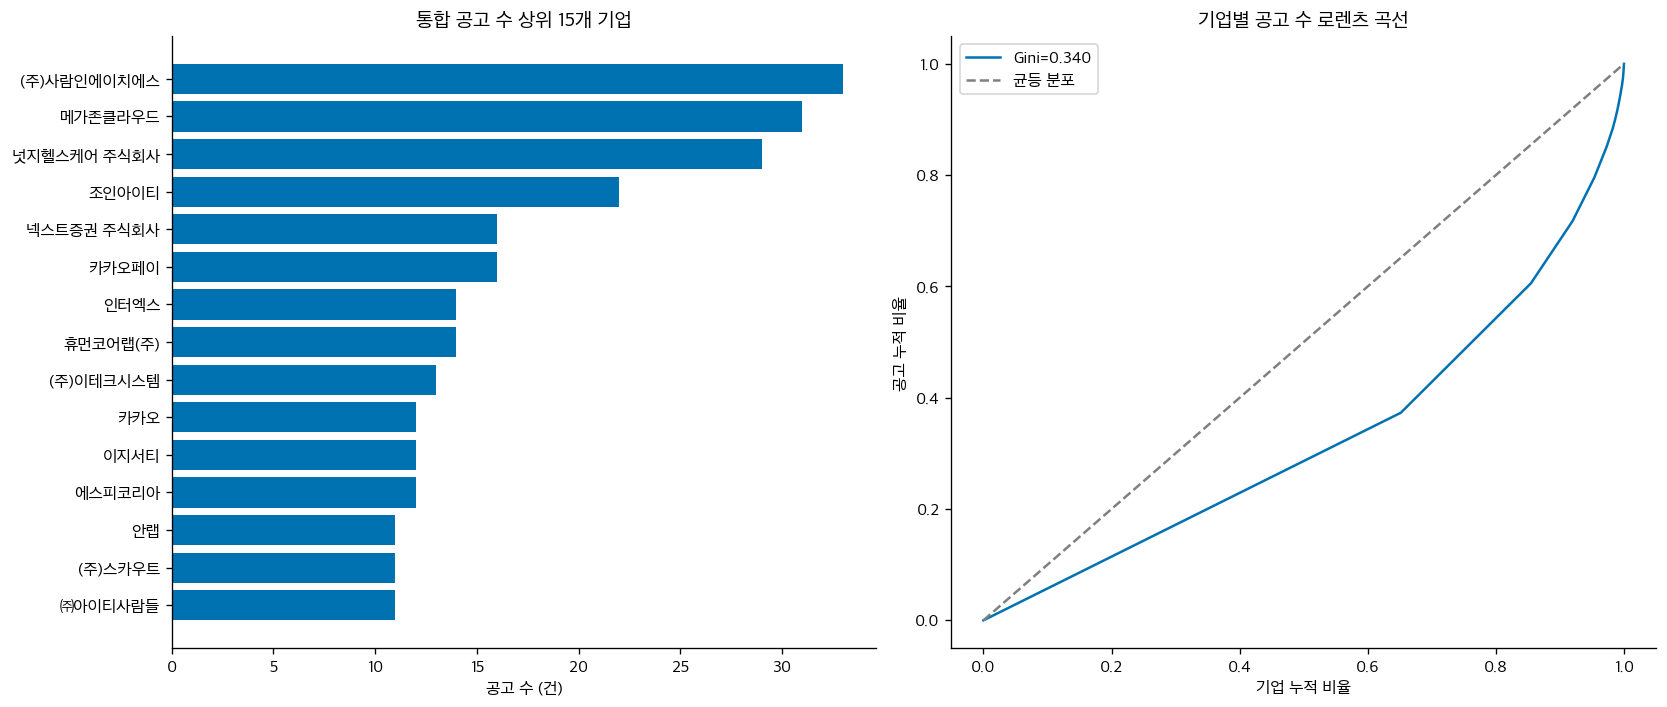

✍️ 정규화 기업 2,615개 중 상위 5%의 공고 점유율은 21.4%, 상위 10%는 31.7%, Gini는 0.340다. 헤드헌팅 업체와 다직무 공고가 포함돼 기업 공고 수가 고용 인원을 뜻하지 않는다.

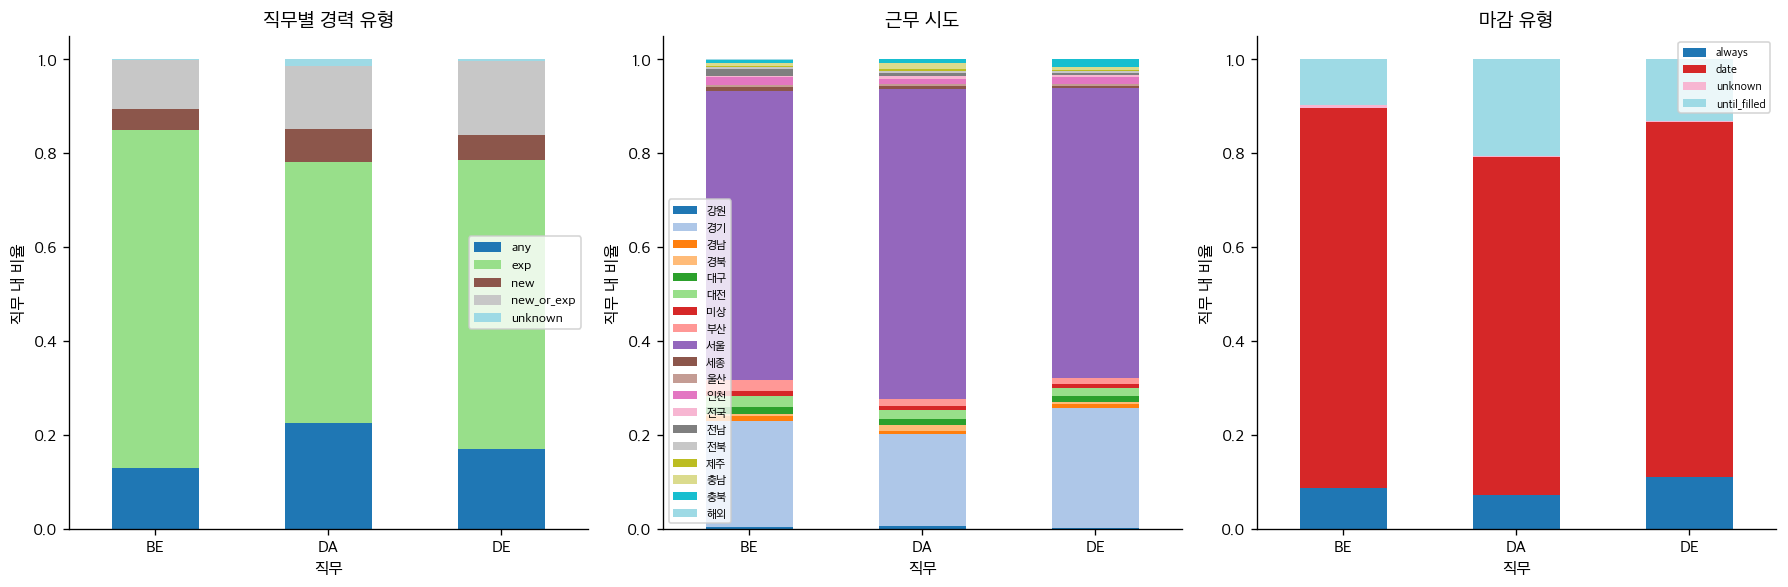

✍️ 신입을 포함하는 공고 비율은 BE 14.8%, DA 20.4%, DE 21.0%다. 대표 공고 기준 수도권 비율은 86.8%이며 지역 결측도 분모에 포함했다. 직무가 여러 개인 통합 공고는 각 직무 안에서 한 번씩 집계한다.

In [5]:
display(Markdown('```sql\n'+eda.QUERIES['Q3'].strip()+'\n```'))
display(snapshot['Q3'].head(10)[['company_name','n','ranking','share','cum_share']])
display(snapshot['Q4'])
display(Markdown(eda.chart_q3(snapshot)))
display(Markdown(eda.chart_q4(snapshot)))

## 4. Q5 게시일 분포와 Q6 중복 게시

**목적:** 현재 목록에 남아 있는 오래된 공고의 영향을 확인하고 플랫폼 중복을 통합한 효과를 측정한다. 게시일 분포는 과거 채용 수요의 시계열이 아니다. 상대 시각은 최초 관측 기준으로 고정하고 수정 표기와 구분한다.

중복 기준은 회사·제목 유사도 0.55·호환 마감·지역과 직무 충돌 제외다. [ETL](job_platform_etl.ipynb)의 임계값 민감도와 표본 검토가 이 추정의 한계를 설명한다. 모든 원천 링크를 보존하여 직접 검토할 수 있다.

,통합 공고 수
posted_precision,
day,4027
hour,237
second,121
none,101
minute,85


,sources,n_sources,n,share
0,[saramin],1,2256,0.49354626996280901335
1,[jobkorea],1,1696,0.37103478451104791074
2,"[jobkorea, saramin]",2,332,0.07263180923211551083
3,[incruit],1,146,0.03194049442135200175
4,[linkareer],1,106,0.02318967403194049442
5,"[incruit, saramin]",2,10,0.00218770509735287683
6,"[incruit, jobkorea]",2,6,0.00131262305841172610
7,"[linkareer, saramin]",2,6,0.00131262305841172610
8,"[jobkorea, linkareer, saramin]",3,5,0.00109385254867643842
9,"[incruit, jobkorea, saramin]",3,4,0.00087508203894115073


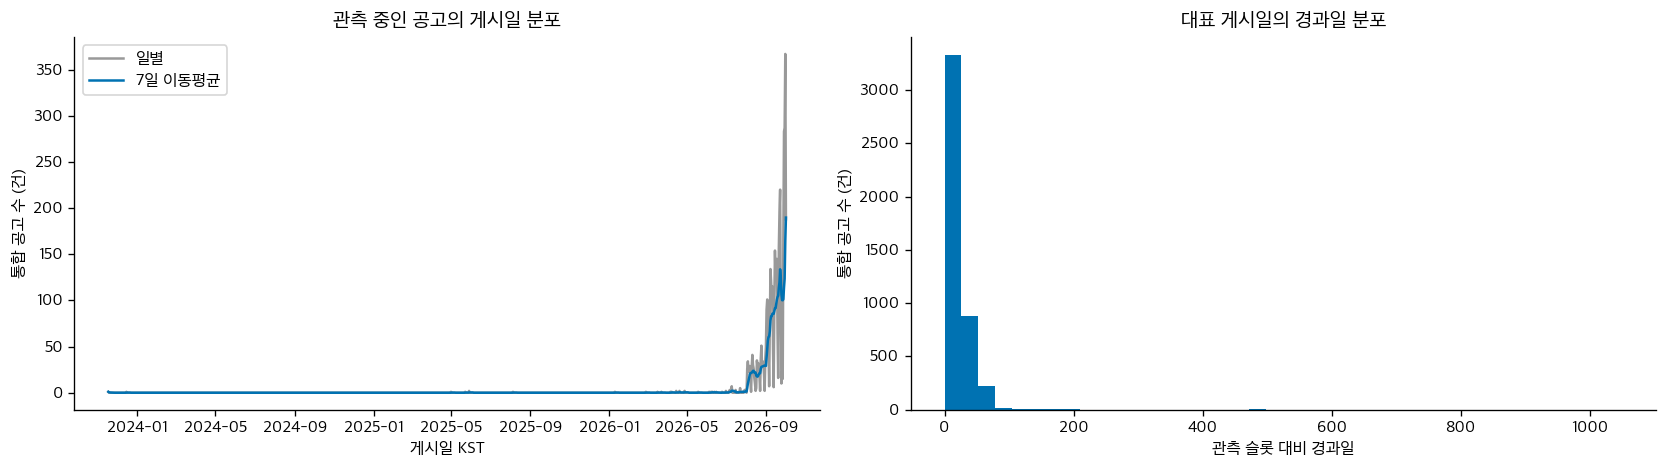

✍️ 대표 게시 시각 결측률은 2.2%다. 게시일 분포는 이번에 목록에 남아 있던 공고의 분포이며 과거 일별 채용 수요 추이가 아니다. 상대 시각은 첫 관측 값으로 고정했고, 등록과 수정 표기는 구분했다.

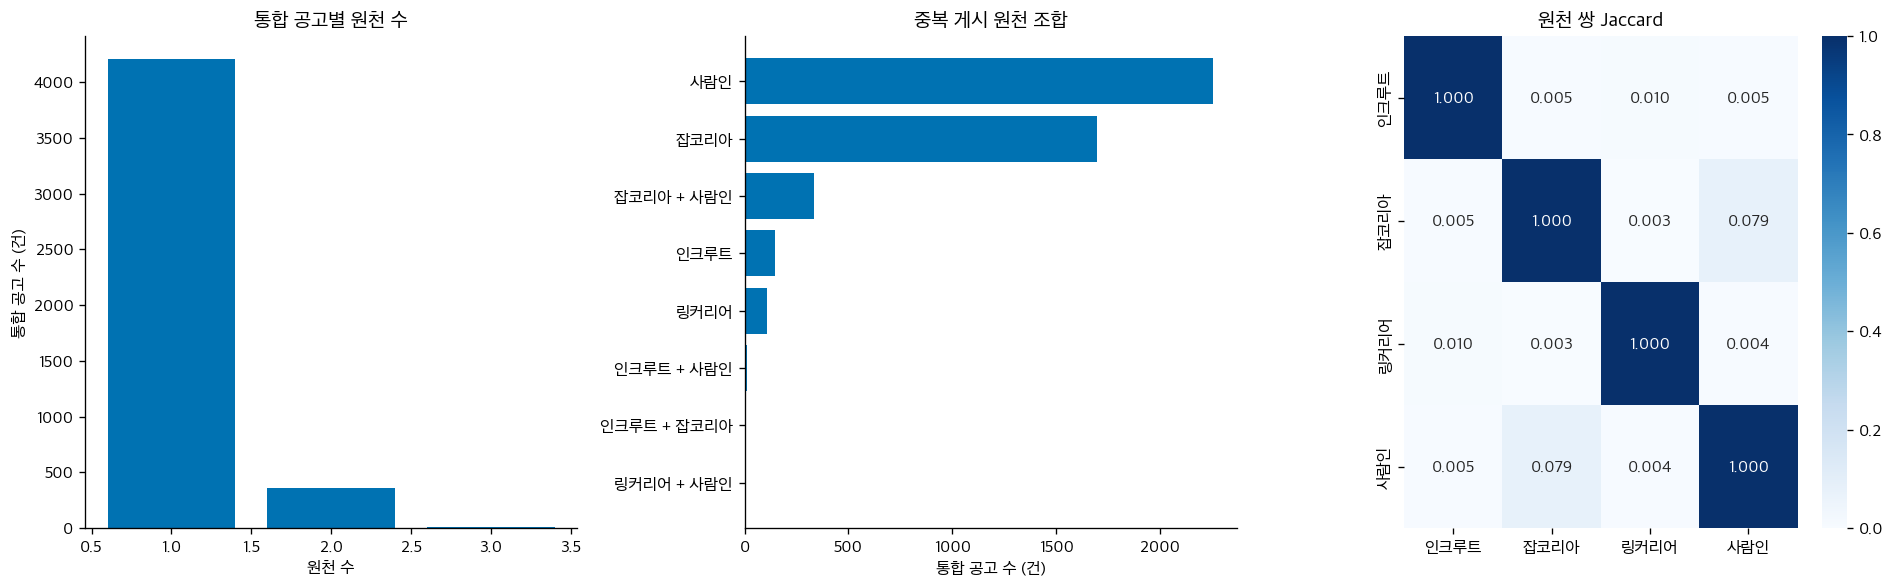

✍️ 현재 판정에서 여러 원천에 게시된 통합 공고는 367건(8.0%)이다. 회사·제목·마감이 호환되는 후보를 묶은 추정치이며, 임계값별 민감도와 표본 검토를 함께 읽어야 한다. 링크 4,964개를 전체 목록에 보존했다.

In [6]:
display(snapshot['features'].posted_precision.value_counts(dropna=False).rename('통합 공고 수').to_frame())
display(snapshot['Q6'])
display(Markdown(eda.chart_q5(snapshot)))
display(Markdown(eda.chart_q6(snapshot)))

## 5. Q7 기술·역량과 직무별 특이성

**목적:** 통합 공고별 키워드를 한 번만 세어 원천 중복으로 빈도가 부풀려지는 것을 막는다. 직무 점유율을 전체 점유율로 나눈 Lift는 해당 직무에서 상대적으로 자주 검출된 기술을 보여준다. 사전 별칭과 경계를 사용하며 JavaScript를 Java로 세지 않는 시험은 ETL에 있다.

목록 태그·제목·읽을 수 있는 상세 텍스트만 사용한다. 이미지 공고와 사전 밖 표현은 검출하지 못하므로 키워드 미검출을 요구 없음으로 해석하지 않는다. 의미 없는 명사 후보 나열과 자동 사전 확대는 제외했다.

```sql
WITH r AS (SELECT DISTINCT x.canonical_id,r.job_group FROM posting_role r JOIN posting_canonical x USING(platform,posting_id) JOIN v_job_scope j USING(canonical_id)),
 s AS (SELECT DISTINCT x.canonical_id,sk.skill,sk.skill_group FROM posting_skill sk JOIN posting_canonical x USING(platform,posting_id) JOIN v_job_scope j USING(canonical_id)),
 freq AS (SELECT r.job_group,s.skill,s.skill_group,count(*) n FROM r JOIN s USING(canonical_id) GROUP BY 1,2,3),
 denom AS (SELECT job_group,count(*) n FROM r GROUP BY 1),overall AS (SELECT skill,count(*) n FROM s GROUP BY 1)
SELECT f.*,f.n::numeric/d.n AS share,(f.n::numeric/d.n)/(o.n::numeric/(SELECT count(*) FROM v_job_scope)) AS lift
FROM freq f JOIN denom d USING(job_group) JOIN overall o USING(skill) ORDER BY job_group,n DESC,skill
```

,job_group,skill,n,share,lift
0,BE,Java,510,0.15572519083969465649,1.36103221286471180658
1,BE,AWS,128,0.03908396946564885496,1.18313128759921136425
3,BE,Spring,105,0.03206106870229007634,1.38255797205818810338
4,BE,Python,104,0.03175572519083969466,0.83422655084671404766
5,BE,C#,88,0.02687022900763358779,1.26622491540096010105
54,DA,Python,55,0.05795574288724973656,1.52250402722769279206
55,DA,SQL,45,0.04741833508956796628,2.64328304505384358433
61,DA,AWS,18,0.01896733403582718651,0.57417009190573555978
63,DA,Java,13,0.01369863013698630137,0.11972550354907147909
64,DA,MySQL,12,0.01264488935721812434,0.91745697225149279953


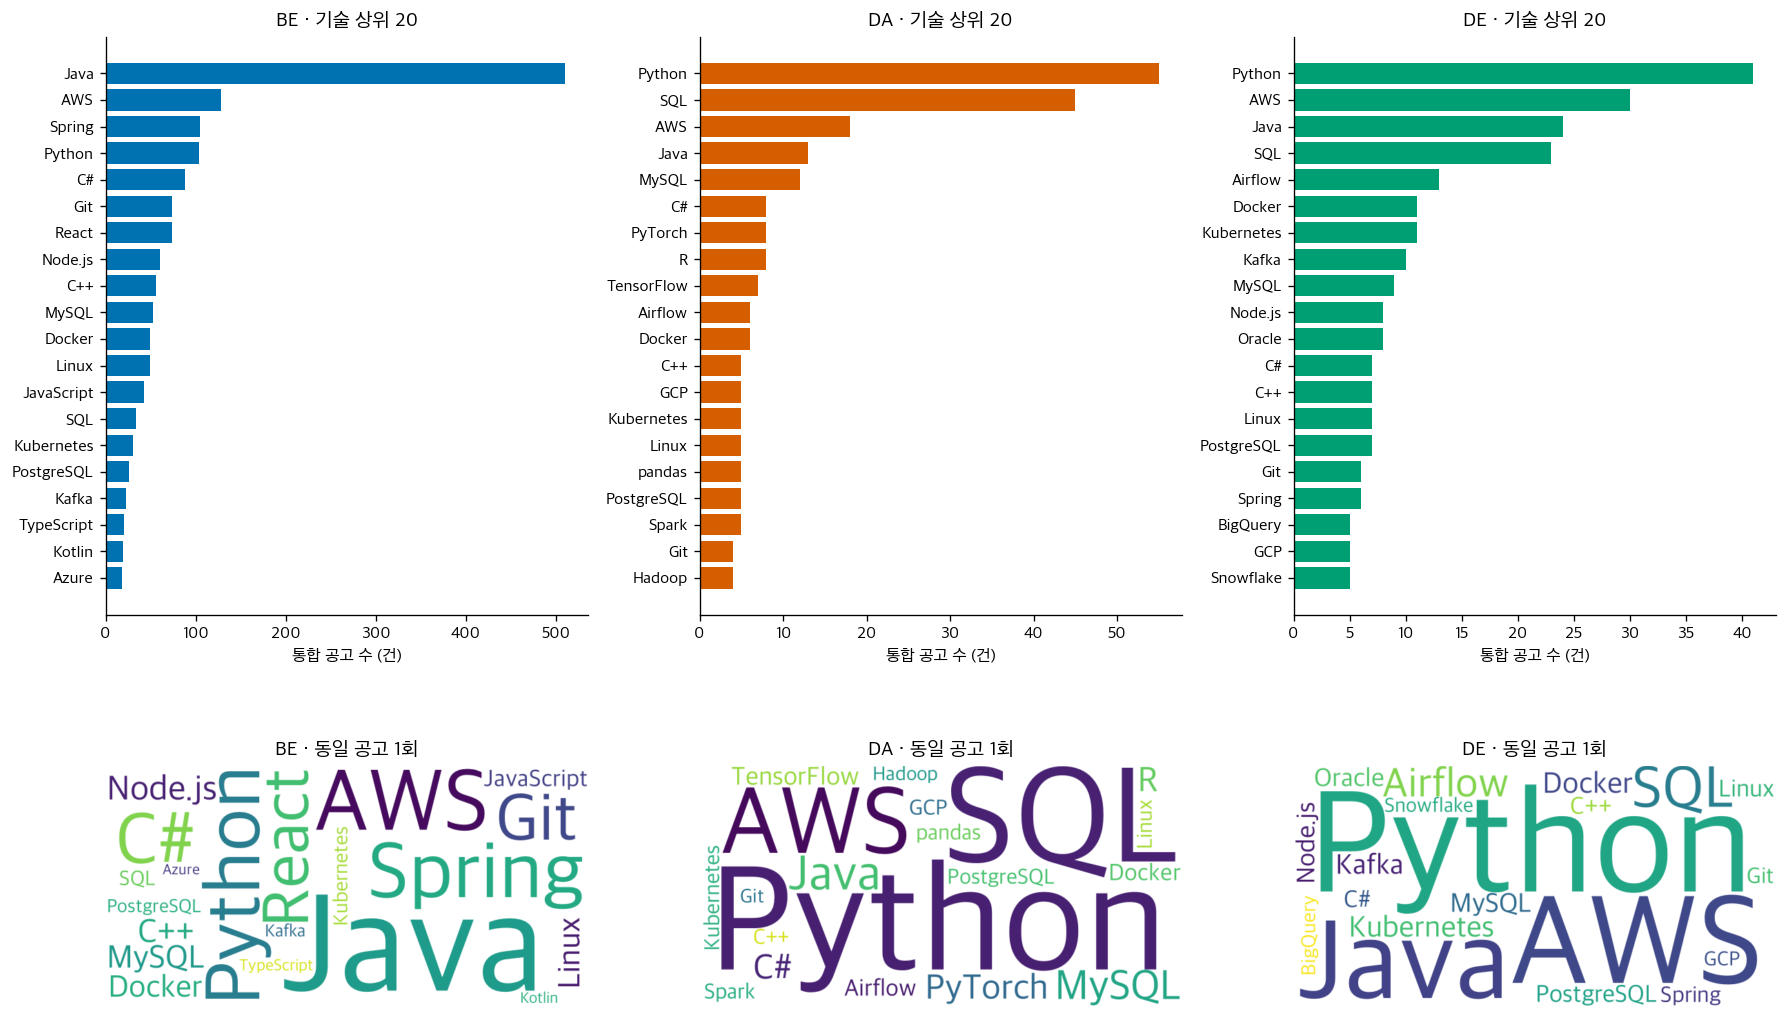

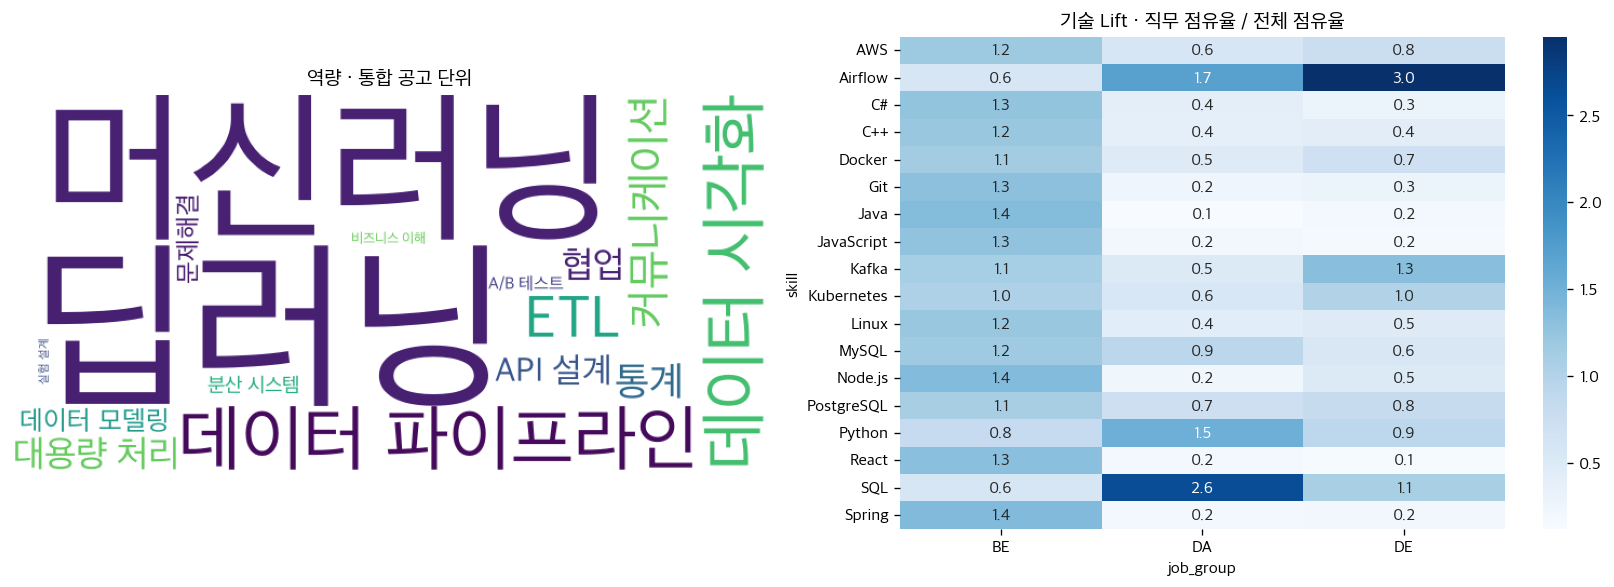

✍️ 기술 키워드가 한 개 이상 검출된 통합 공고는 24.7%다. 제목·목록 태그와 읽을 수 있는 상세 텍스트를 사전으로 검색한 결과다. 이미지로만 제공된 자격요건과 사전 밖 표현은 관측하지 못하므로 미검출이 요구 없음으로 해석되지 않는다. 워드클라우드의 크기는 수요 인원이 아니라 공고 빈도다.

In [7]:
display(Markdown('```sql\n'+eda.QUERIES['Q7'].strip()+'\n```'))
display(snapshot['Q7'][snapshot['Q7'].skill_group.eq('technology')].groupby('job_group').head(5)[['job_group','skill','n','share','lift']])
display(Markdown(eda.chart_q7(snapshot)))

## 6. Q8 상관과 공출현

**목적:** 경력·키워드 수·게시 경과일 등의 동반 변화를 탐색한다. Spearman은 유효 쌍 30개 이상과 비상수 변수에만 계산한다. 상위 기술 공출현은 통합 공고의 이진 지표로 Phi를 계산한다. 범주 검정은 단일 직무 공고만 사용하고 기대빈도 5 미만이면 p값을 보류한다.

상관 쌍의 n·p·BH FDR 보정 q값을 CSV에 보존한다. 시차 상관은 연속 변화량 표본이 충분할 때만 그림을 만든다. 검정은 탐색적이며 인과관계나 직무 효과를 확정하지 않는다.

,variables,n,chi2,p,cramers_v,min_expected,p_valid
0,role × career_type,3874,127.9747,NaN,0.1285,1.4001,False
1,role × region,3874,19.2622,0.0037,0.0499,8.4006,True
2,platform × career_type,3874,698.3111,NaN,0.2451,0.2726,False
3,cross_posted × role,3874,41.8019,0.0000,0.1039,32.6691,True


,A,B,n,rho,p,q_BH
0,career_min_yr,career_max_yr,937,0.8025,0.0000,0.0000
21,days_to_deadline,posted_age_days,3529,-0.3174,0.0000,0.0000
28,posted_age_days,always_open,4470,0.1501,0.0000,0.0000
6,career_min_yr,company_postings,3591,0.1349,0.0000,0.0000
17,skill_count,n_sources,4571,0.1216,0.0000,0.0000
18,skill_count,title_length,4571,0.1190,0.0000,0.0000
3,career_min_yr,posted_age_days,3510,-0.1045,0.0000,0.0000
34,company_postings,always_open,4571,0.1028,0.0000,0.0000
9,career_max_yr,days_to_deadline,750,-0.0996,0.0064,0.0171
30,n_sources,company_postings,4571,-0.0858,0.0000,0.0000


유효 시차 결과: 25 개 · 0개이면 시차 그림 제외


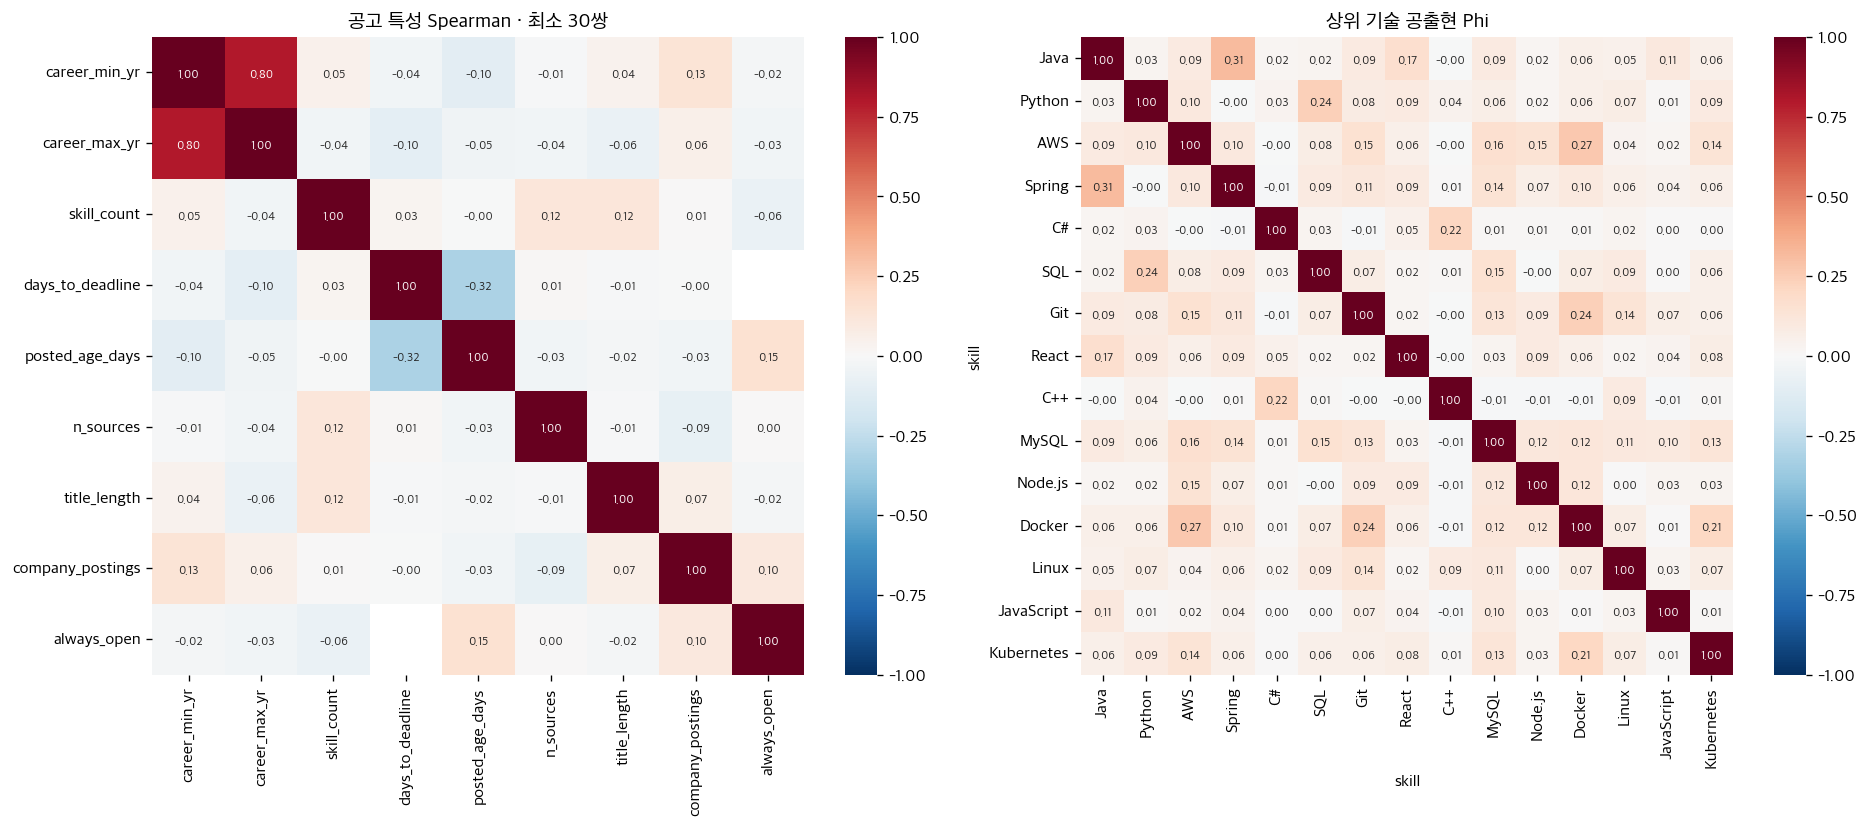

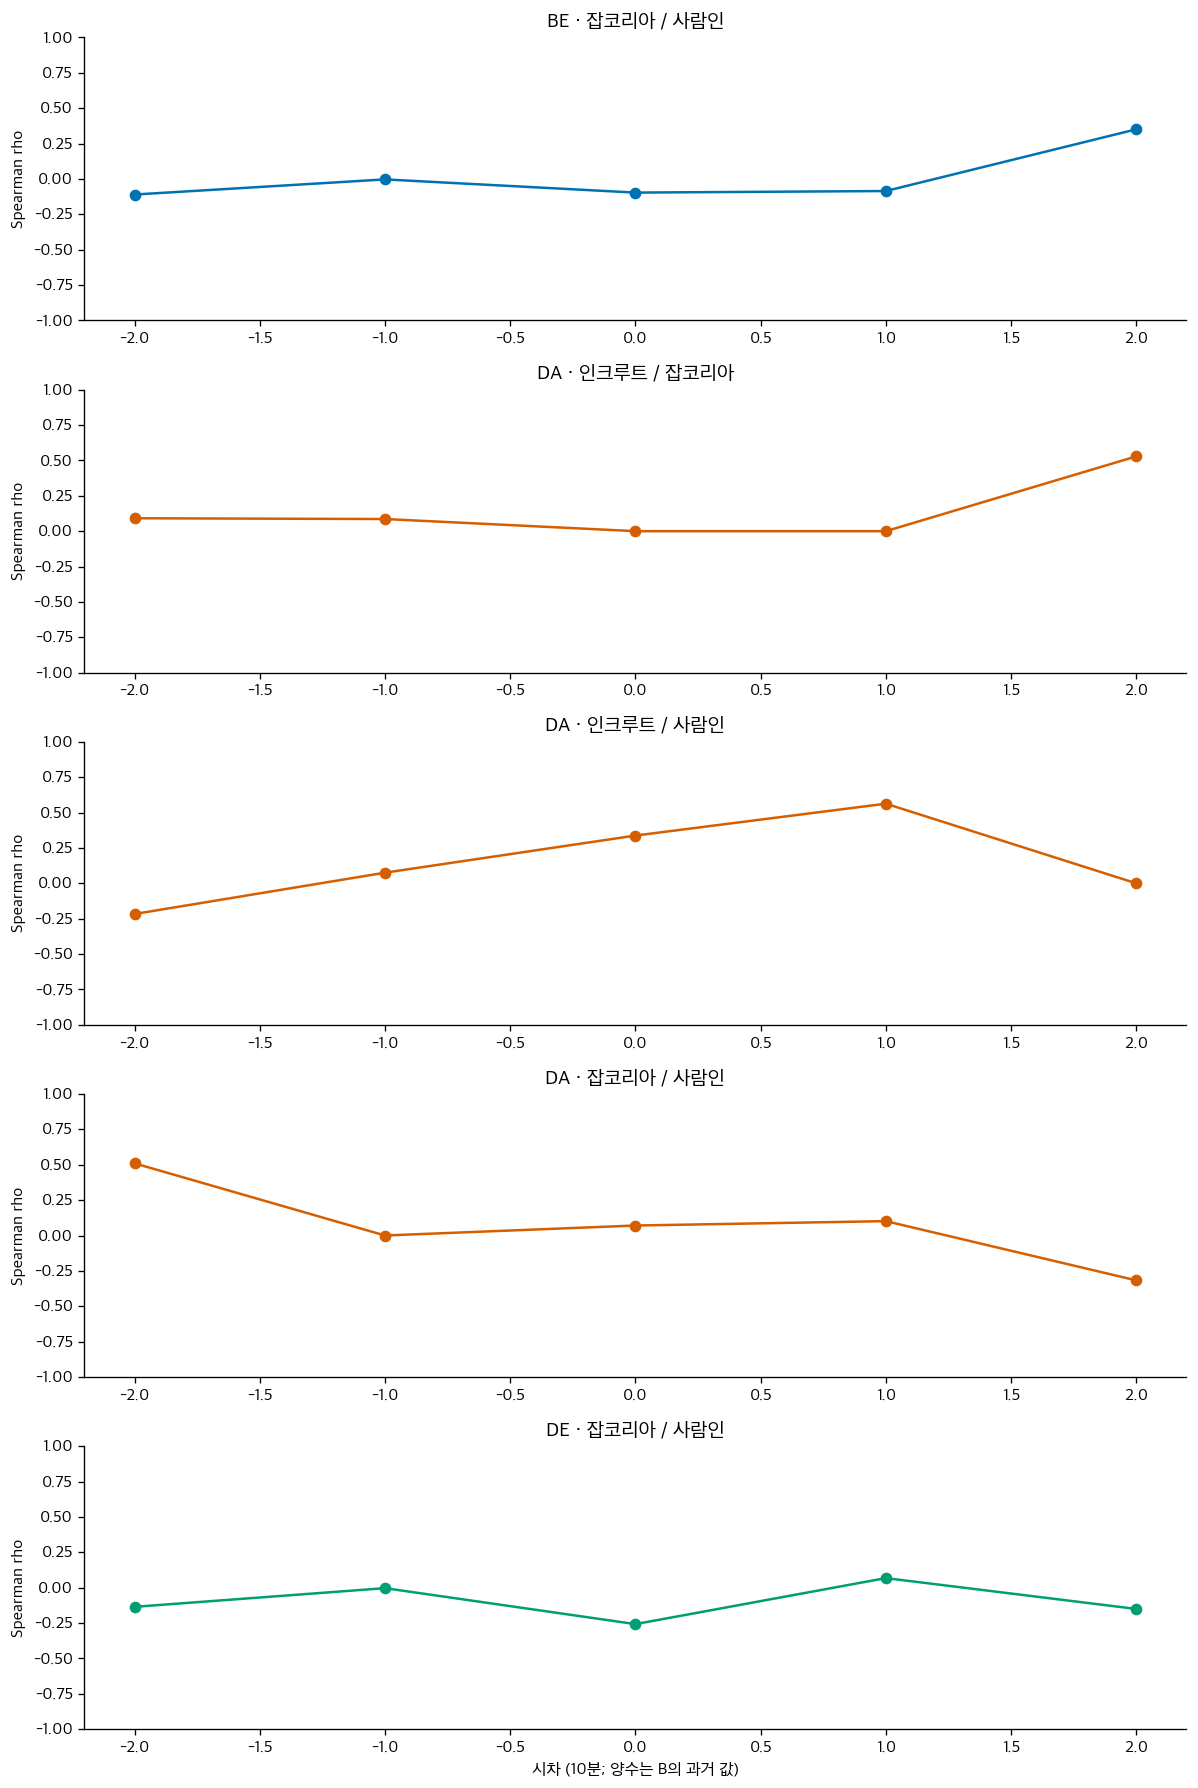

✍️ 상관은 인과관계를 뜻하지 않는다. p값·유효 쌍 수·상관 쌍의 BH FDR 보정 q값을 CSV에 보존하고 결측을 쌍별로 제외했다. 범주 검정은 단일 직무 공고만 사용해 복수 직무 697건을 제외했으며 기대빈도 5 미만인 검정의 p값은 보류한다. 범주 검정은 보정 전 탐색 통계이며, 어느 결과도 확증적 인과 결론으로 사용하지 않는다.

In [8]:
stats8=eda.stats_q8(snapshot)
display(stats8['associations'].round(4))
pair_rows=[]
for i,a in enumerate(stats8['rho'].columns):
    for b in stats8['rho'].columns[i+1:]:
        rho=stats8['rho'].loc[a,b]
        if pd.notna(rho):pair_rows.append({'A':a,'B':b,'n':int(stats8['n'].loc[a,b]),'rho':rho,'p':stats8['p'].loc[a,b],'q_BH':stats8['qvalue'].loc[a,b]})
pairs=pd.DataFrame(pair_rows)
if not pairs.empty:display(pairs.assign(abs_rho=pairs.rho.abs()).sort_values('abs_rho',ascending=False).drop(columns='abs_rho').head(10).round(4))
print('유효 시차 결과:',int(stats8['lags'].rho.notna().sum()), '개 · 0개이면 시차 그림 제외')
display(Markdown(eda.chart_q8(snapshot,stats8)))

## 7. Q9 분포와 이상치 판단

**목적:** 기업당 공고 수·최소 경력·마감까지 일수 등의 긴 꼬리를 확인한다. IQR 1.5배 울타리와 표준편차 3배 기준을 비교하되 이상치를 자동 삭제하지 않는다. 기업 다직무 공고는 실제 분포의 꼬리일 수 있고 마감이 게시보다 빠른 값은 별도 유효성 문제다. IQR=0인 희소 신규 수·키워드는 작은 양수도 이상치가 될 수 있다.

,변수,n,q1,q3,IQR,lower,upper,IQR_outliers,std_outliers,skew,kurtosis
0,기업당 공고 수,2615,1.000,2.000,1.0,-0.500,3.500,211,41,7.359,90.443
1,마감까지 일수,3602,8.299,28.299,20.0,-21.701,58.299,65,2,38.003,1551.920
2,최소 경력,3591,1.000,5.000,4.0,-5.000,11.000,30,22,0.852,0.752
3,기술 수,4571,0.000,0.000,0.0,0.000,0.000,1129,74,4.487,34.618
4,10분 신규 수,220,0.000,1.000,1.0,-1.500,2.500,13,5,2.576,7.806


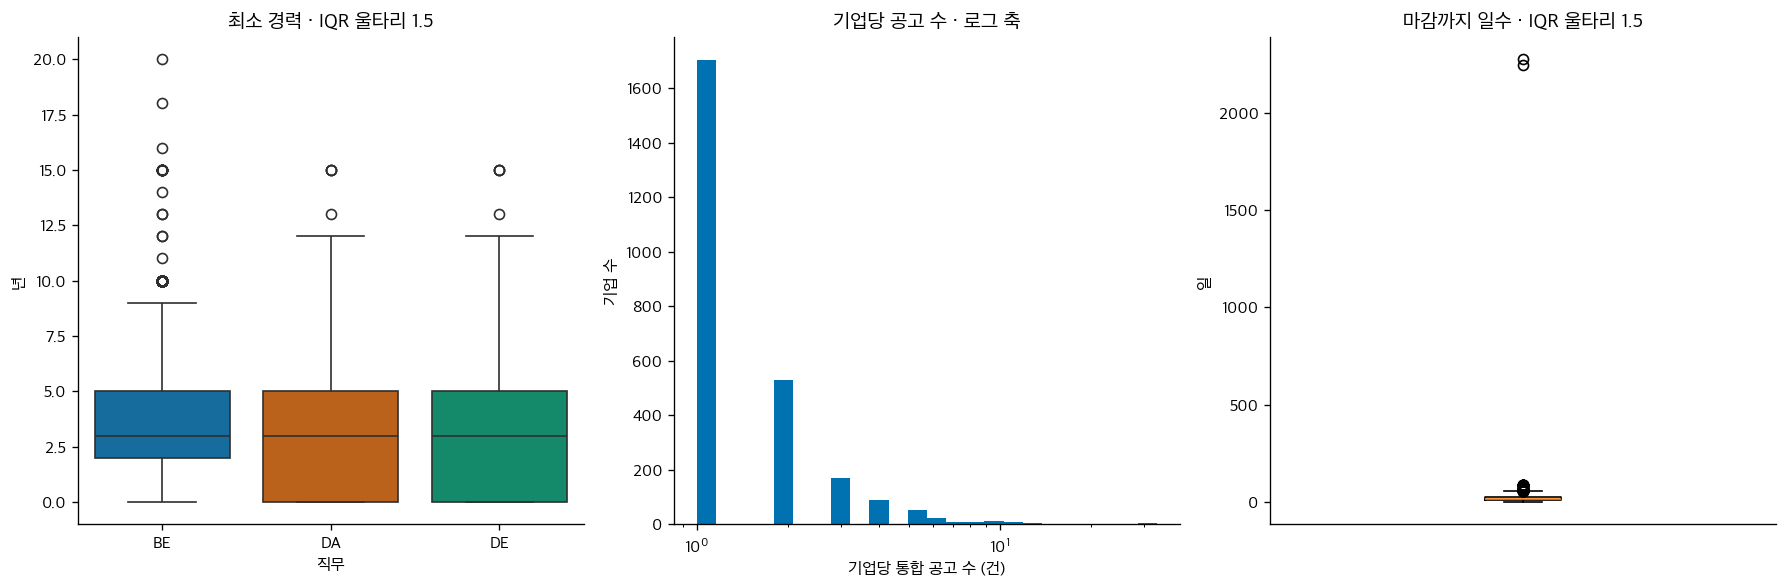

✍️ 변수별 IQR 규칙은 총 1,448개 관측값을 표시했다(동일 공고의 변수 중복 포함). IQR=0인 희소 키워드·신규 수에서는 양수가 모두 이상치가 될 수 있어 오류 판정으로 쓰지 않는다. 상시 마감의 NULL과 2070 센티널은 실제 마감까지 일수로 계산하지 않는다. Kruskal-Wallis 결과 {'H': np.float64(53.61464065125649), 'p': np.float64(2.27891804871726e-12), 'n': [2377, 300, 401]}도 탐색적이며 직무 분류·결측의 차이를 함께 고려해야 한다.

In [9]:
stats9=eda.stats_q9(snapshot)
display(stats9[0].round(3))
display(Markdown(eda.chart_q9(snapshot,stats9)))

## 분석 결과와 재실행

[전체 공고 웹 화면](web/index.html) · [운영 문서](docs/RUNBOOK.md)

저장 자료로 다시 분석하려면 프로젝트 폴더에서 `python scripts/run_notebook.py`를 실행한다. 통합·원천 공고, 상관 통계와 IQR 경계 CSV는 `reports/`에 생성된다. 20:00 최종 실행이 종료되면 자동 마무리 프로세스가 세 노트북과 웹 자료를 갱신한다.

이 자료는 하루의 부분 관측·플랫폼 직무 코드의 범위 차이·목록 광고와 끌어올리기·상세 수집 대기·살아남은 공고의 편향을 포함한다. 기업별 공고 수는 고용 인원이 아니며 중복 통합과 키워드 검출은 추정이다.

In [10]:
with store.connect() as conn:
    final_slot=conn.execute("SELECT status FROM crawl_run WHERE run_kind='scheduled' AND slot_ts=timestamptz '2026-10-02 20:00+09'").fetchone()
finished=bool(final_slot and final_slot[0] in ('success','partial'))
checks={'SQL/pandas 교차 검증':all(v is True for v in validation.values() if isinstance(v,bool)),
        '원천 링크 누락 0':catalog_evidence['source_links']==len(snapshot['postings']),
        '필수 값 누락 0':int(snapshot['validity'].required_missing.sum())==0,
        '2070 센티널 잔존 0':int(snapshot['validity'].sentinel_leaks.sum())==0}
assert all(checks.values()),checks
display(pd.DataFrame(checks.items(),columns=['검증','통과']))
display(Markdown('**'+('최종 수집 자료' if finished else '부분 수집 자료 · 20:00 최종 실행 대기')+'** · 기준 슬롯 '+snapshot['asof']))
report={'asof':snapshot['asof'],'final_slot':finished,'validation':validation,'catalog':catalog_evidence,'checks':checks}
Path('reports/analysis_validation.json').write_text(json.dumps(report,ensure_ascii=False,indent=2))

,검증,통과
0,SQL/pandas 교차 검증,True
1,원천 링크 누락 0,True
2,필수 값 누락 0,True
3,2070 센티널 잔존 0,True


**부분 수집 자료 · 20:00 최종 실행 대기** · 기준 슬롯 2026-10-02 16:50:00+09:00

497